# 承認済み部位別 before / after を解析する

`video_region_pair_candidates.ipynb` で固定した `selected_region_pairs.json` を使います。
現在選択されている部位だけを解析し、別部位のペアへ自動で置き換えません。


In [6]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
marker = Path('analysis/analyze_selected_regions.py')
if (cwd / marker).is_file():
    REPO_ROOT = cwd
elif cwd.name == 'notebooks' and (cwd.parent / marker).is_file():
    REPO_ROOT = cwd.parent
    os.chdir(REPO_ROOT)
else:
    raise RuntimeError(f'ikiikimake のリポジトリ直下または notebooks/ から実行してください: current={cwd}')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print('repo root:', Path.cwd())


repo root: C:\Users\mail\work\ikiikimake


In [7]:
VIDEO = Path('makeup0923.mp4')
OUTPUT = Path('outputs') / VIDEO.stem
SELECTED = OUTPUT / 'selected_region_pairs.json'
ANALYSIS_ROOT = OUTPUT / 'selected_region_analysis'

if not SELECTED.is_file():
    raise FileNotFoundError(f'部位別ペアが固定されていません: {SELECTED}')
print('selected:', SELECTED)


selected: outputs\makeup0923\selected_region_pairs.json


analysis: C:\Users\mail\work\ikiikimake\outputs\makeup0923\selected_region_analysis\50234fe53483a3c6


指標,単位,before,after,差,状態
画面左目の下の細かな質感コントラスト（中央値）,局所L*比 %,0.335,1.634,+1.299,ok
画面左目の下の細かな質感コントラスト（p90）,局所L*比 %,0.829,7.002,+6.172,ok
画面右目の下の細かな質感コントラスト（中央値）,局所L*比 %,0.184,1.492,+1.307,ok
画面右目の下の細かな質感コントラスト（p90）,局所L*比 %,0.551,8.152,+7.601,ok

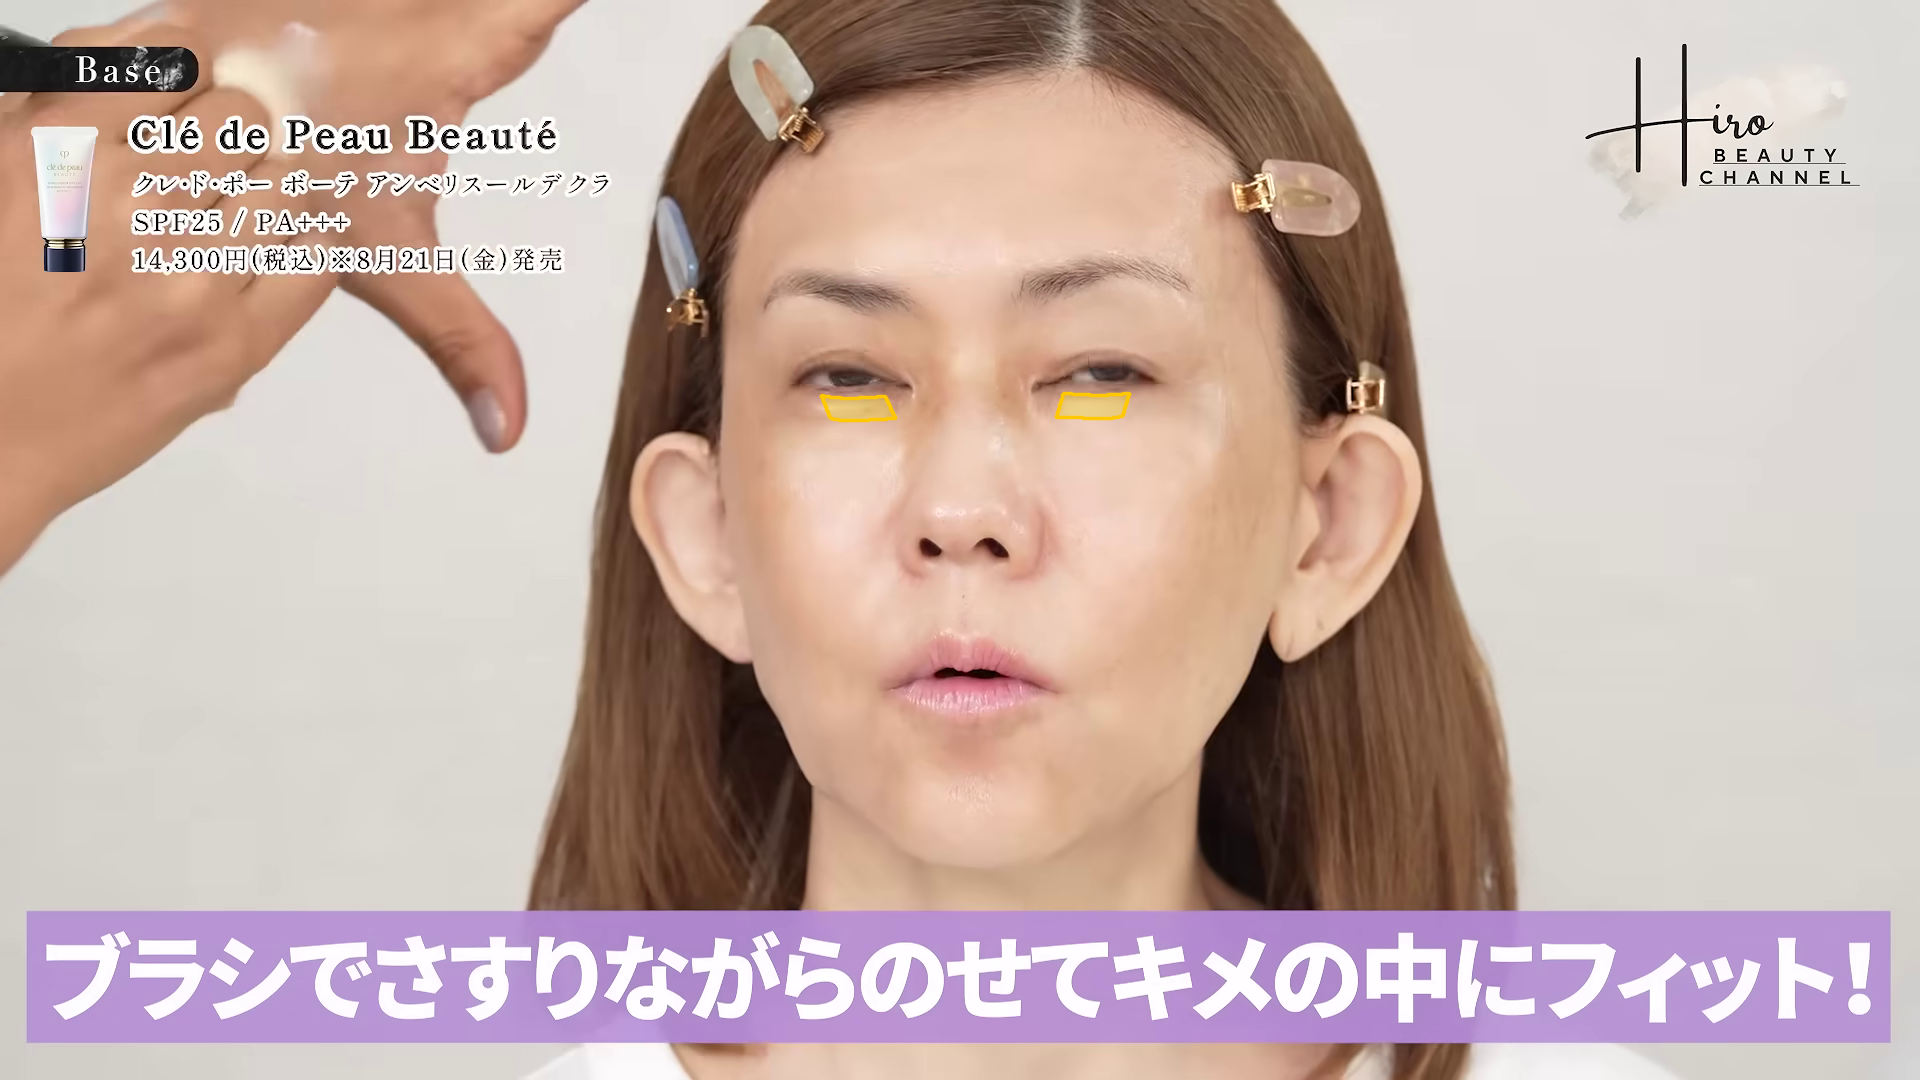
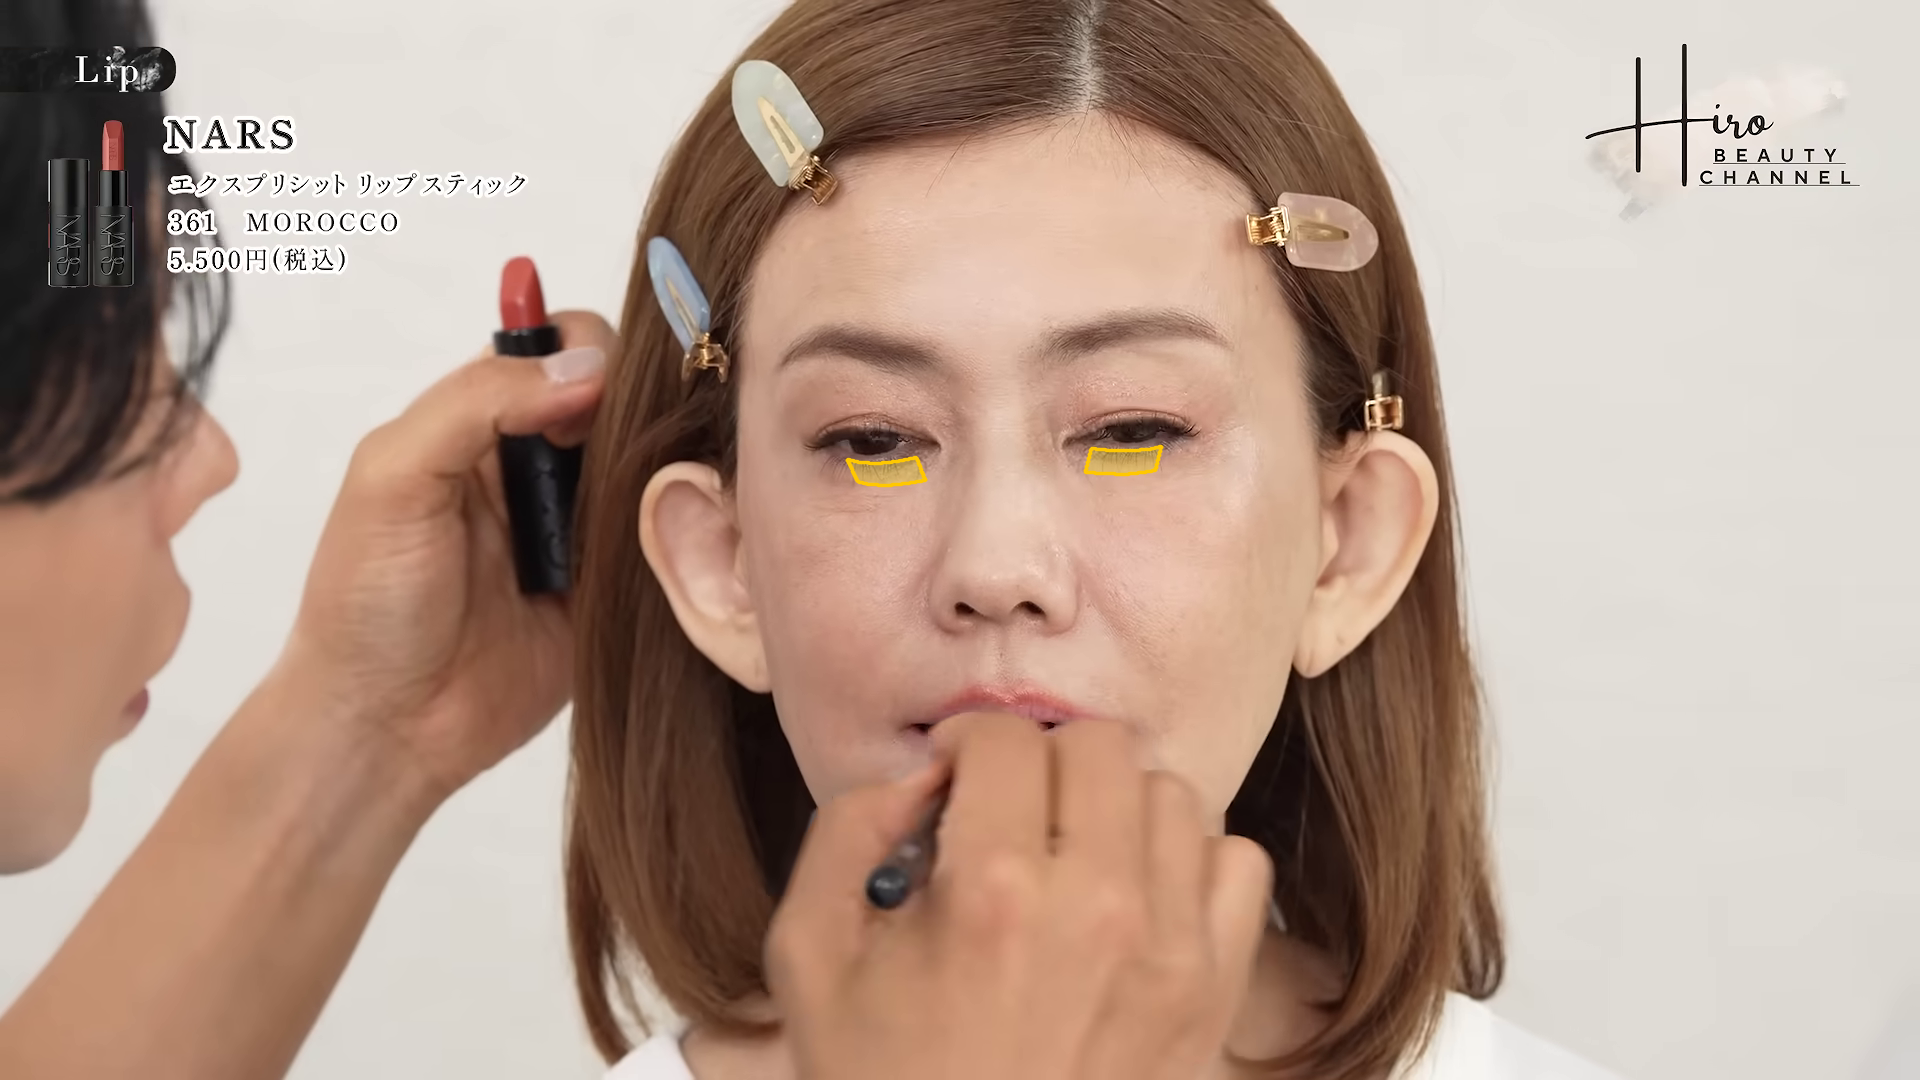

In [8]:
from analysis.analyze_selected_regions import analyze_selected_regions
from IPython.display import HTML, display
import base64

summary = analyze_selected_regions(SELECTED, ANALYSIS_ROOT)
RUN_DIR = Path(summary['output_dir'])
print('analysis:', RUN_DIR)

# report.html 内の相対画像パスは VS Code/Jupyter の HTML 表示では
# notebook 側を基準に解決されて壊れるため、表示時だけ data URI に埋め込む。
report_html = (RUN_DIR / 'report.html').read_text(encoding='utf-8')
for region in summary['regions']:
    for phase in ('before', 'after'):
        filename = f'{region}_{phase}.png'
        image_path = RUN_DIR / filename
        if not image_path.is_file():
            raise FileNotFoundError(image_path)
        encoded = base64.b64encode(image_path.read_bytes()).decode('ascii')
        report_html = report_html.replace(
            f"src='{filename}'",
            f"src='data:image/png;base64,{encoded}'",
        )
display(HTML(report_html))


In [9]:
for region, result in summary['regions'].items():
    print('\n', region)
    for row in result['deltas']:
        before = row['before']
        after = row['after']
        delta = row['delta']
        print(f"{row['label']}: {before:.4f} -> {after:.4f}  delta={delta:+.4f}")
print('\nreport:', RUN_DIR / 'report.html')
print('csv   :', RUN_DIR / 'feature_deltas.csv')



 eye_texture
画面左目の下の細かな質感コントラスト（中央値）: 0.3350 -> 1.6342  delta=+1.2992
画面左目の下の細かな質感コントラスト（p90）: 0.8295 -> 7.0019  delta=+6.1725
画面右目の下の細かな質感コントラスト（中央値）: 0.1843 -> 1.4917  delta=+1.3074
画面右目の下の細かな質感コントラスト（p90）: 0.5513 -> 8.1519  delta=+7.6005

report: C:\Users\mail\work\ikiikimake\outputs\makeup0923\selected_region_analysis\50234fe53483a3c6\report.html
csv   : C:\Users\mail\work\ikiikimake\outputs\makeup0923\selected_region_analysis\50234fe53483a3c6\feature_deltas.csv


In [10]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

analysis_file = PROJECT_ROOT / "analysis" / "analyze_selected_regions.py"

if not analysis_file.is_file():
    raise FileNotFoundError(
        f"Module file not found: {analysis_file}\n"
        f"cwd: {Path.cwd()}\n"
        f"PROJECT_ROOT: {PROJECT_ROOT}"
    )

sys.path.insert(0, str(PROJECT_ROOT))

from analysis.analyze_selected_regions import _load_phase

FileNotFoundError: Module file not found: C:\Users\mail\work\analysis\analyze_selected_regions.py
cwd: C:\Users\mail\work\ikiikimake
PROJECT_ROOT: C:\Users\mail\work

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from analysis.analyze_selected_regions import _load_phase

region = "eye_texture"
selection = summary["regions"][region]["selection"]

before_img, before_masks, _ = _load_phase(selection["before"], region)
after_img, after_masks, _ = _load_phase(selection["after"], region)

def make_closeup(image, mask, pad=20, scale=6):
    ys, xs = np.where(mask)
    if len(ys) == 0:
        raise ValueError("mask is empty")

    y0 = max(0, ys.min() - pad)
    y1 = min(image.shape[0], ys.max() + pad + 1)
    x0 = max(0, xs.min() - pad)
    x1 = min(image.shape[1], xs.max() + pad + 1)

    crop = image[y0:y1, x0:x1].copy()
    local_mask = mask[y0:y1, x0:x1]

    fill = crop.copy()
    fill[local_mask] = (50, 220, 240)
    overlay = cv2.addWeighted(fill, 0.35, crop, 0.65, 0)

    contours = cv2.findContours(
        local_mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )[0]
    cv2.drawContours(overlay, contours, -1, (0, 200, 255), 1, cv2.LINE_AA)

    overlay = cv2.resize(
        overlay, None, fx=scale, fy=scale, interpolation=cv2.INTER_NEAREST
    )
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    return overlay

mask_names = [
    ("screen_left_lower_eye_skin", "画面左目の下"),
    ("screen_right_lower_eye_skin", "画面右目の下"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

for row, (mask_name, title) in enumerate(mask_names):
    before_view = make_closeup(before_img, before_masks[mask_name])
    after_view = make_closeup(after_img, after_masks[mask_name])

    axes[row, 0].imshow(before_view)
    axes[row, 0].set_title(f"before: {title}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(after_view)
    axes[row, 1].set_title(f"after: {title}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

NameError: name 'summary' is not defined